# GENERAL NOTES
aims:
* Analysis of the results output derived from the [too-many-cells](https://github.com/GregorySchwartz/too-many-cells) program, an entire pipeline was created in order to utilize [too-many-cells](https://github.com/GregorySchwartz/too-many-cells) with [ImmuneDB](https://github.com/arosenfeld/immunedb) BCR sequences, this pipeline is called [tmc_preprocessing](https://github.com/dani-f99/tmc_preprocessing), so in order to use this tmc_processing pipeline first you need to run [tmc_preprocessing](https://github.com/dani-f99/tmc_preprocessing) and use the `cluster_tree.json` and `labels.csv files` as input.
* Use the results derived from [tms_preprocessing]() in order to utilize the [find_clumpiness](https://github.com/GregorySchwartz/find-clumpiness) algorithm in order to see how much "clumped" are the cells with each metadata labels.

Publications:
* [too-many-cells-python](https://www.nature.com/articles/s41592-020-0748-5)
* [too-many-cells-interactive](https://academic.oup.com/gigascience/article/doi/10.1093/gigascience/giae056/7738847?login=false)
* [find-clumpiness](http://www.sciencedirect.com/science/article/pii/S0167865516000234)

---
# CLUSTERS ANALYSIS
With this analysis code we can explore two aspects of the [tmc_preprocessing](https://github.com/dani-f99/tmc_preprocessing) output:
* We can get output dataframe which will describe a selected `cluster_tree` node, with assosiation to cluster and metadatalabels.
* We can visualize with pie chart the metadata distrubtion (of cells) whitin each wanted node.

In [1]:
# Loading up the script from the source folder.
# WILL CREATE REQUIRED FOLDERS - LOAD FIRST
from source.clusters_analysis import cluster_analysis

> 4/4 packages are installed:
pandas package is Installed (v2.3.3)
numpy package is Installed (v2.2.6)
matplotlib package is Installed (v3.10.8)
seaborn package is Installed (v0.13.2)
> folder `input` exists, continuing.
> folder `output` exists, continuing.
> folder `input\covid_vaccine_new-subject7` exists, continuing.
> folder `output\covid_vaccine_new-subject7` exists, continuing.


In [2]:
# In this analysis, we will choose subject number 7.
# Metadata labels and relabels fitting the tmc_preprocessing output.
cluster = cluster_analysis(subject_id = 7,
                                metadata_labels = ["cell_subset","collection_time_point_relative"],
                                metadata_relabels = ["ab_target", "time_point"])

In [3]:
# Let's get information about the cells whitin node `99132` (for example).
node_cells = cluster.lookup_node(node_id = 43129)
node_cells.head(3)

,sp_cluster,sp_path,ab_target,time_point
DFAIFGVVPPAYWGQGTLVT,43149,43149/43148/43147/43131/43130/43129/43089/4308...,Spike+ Mem B,2 weeks
YYCATDFAIFGVVPPAYWGQ,43149,43149/43148/43147/43131/43130/43129/43089/4308...,Spike+ Mem B,2 weeks
VYYCATDFAIFGVVPPAYWG,43149,43149/43148/43147/43131/43130/43129/43089/4308...,Spike+ Mem B,2 weeks


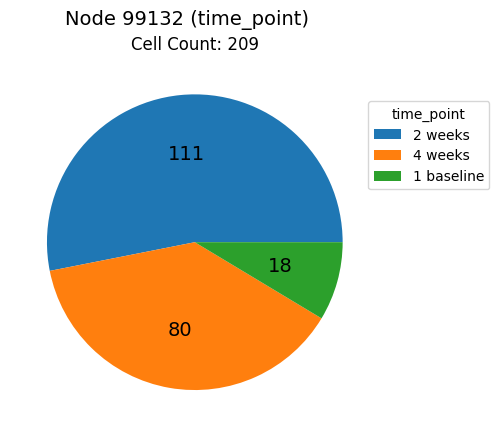

In [4]:
# Now let's visualize the cell count via pie chart - focus on "time_point" column.
cluster.plot_node(node_id = 43129,
                       by = ["time_point"])

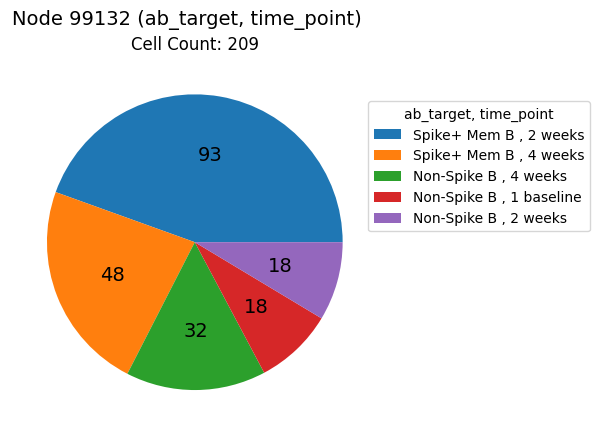

In [5]:
#now, if we want to plot the data by two labels, for example 'time_point' and 'ab_target':
cluster.plot_node(node_id = 43129,
                       by = ["ab_target", "time_point"])

---
# CLUMPINESS ANALYSIS
With this analysis code we:
- Generate suitible input json file for the [find-clumpiness](https://github.com/GregorySchwartz/find-clumpiness) program.
- Use find_clumpiness program in order to get clumpiness csv output.
- Visuzlize the clumpiness results using seaborn heatmap.

In [1]:
# Import the clumpiness code
import source.clumpiness_analysis as ca
import os

> 4/4 packages are installed:
pandas package is Installed (v2.3.3)
numpy package is Installed (v2.2.6)
matplotlib package is Installed (v3.10.8)
seaborn package is Installed (v0.13.2)
> folder `input` exists, continuing.
> folder `output` exists, continuing.
> folder `input\covid_vaccine_new-subject7` exists, continuing.
> folder `output\covid_vaccine_new-subject7` exists, continuing.


In [7]:
# Generate suitible input for find-clumpiness algorithm based on the tmc_preprocessing output.
ca.clumpiness_json()

`find_clumpiness_input.json` Saved at output\covid_vaccine_new-subject7.


Plot without_pruning saved to `output\covid_vaccine_new-subject7\clumpiness_heatmap-without_pruning.png`.


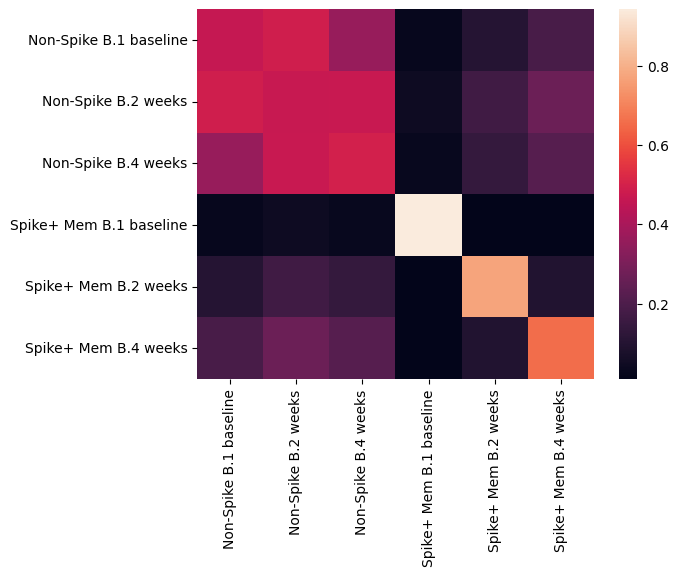

In [4]:
# Version of clumpiness csv without cluster tree pruning.
ca.clumpiness_heatmap(dataset = os.path.join("input", "covid_vaccine_new-subject7", "clumpiness_without_pruning.csv"),
                      plot_name = "without_pruning")

Plot with_pruning saved to `output\covid_vaccine_new-subject7\clumpiness_heatmap-with_pruning.png`.


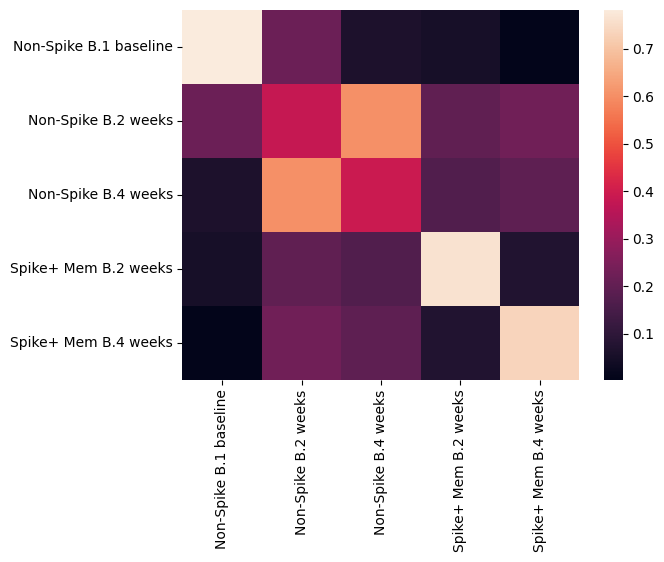

In [5]:
# Version of clumpiness csv with cluster tree pruning.
ca.clumpiness_heatmap(dataset = os.path.join("input", "covid_vaccine_new-subject7", "clumpiness_pruned.csv"),
                      plot_name = "with_pruning")